# Manchester Temperature Prediction 

## Structure
- Common imports, config, and data loading
- One combined cell for **XGB + LGBM + RF**
- One dedicated cell for **SVR**
- One dedicated cell for **SVR_PCA**
- Final comparison plots and exported prediction tables




In [1]:

import warnings
warnings.filterwarnings("ignore")

import os
import h5py
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [7]:

# ==========================================
# Config
# ==========================================
FILES = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc",
]

PREDICTORS = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT']
TARGET = 'TREFMXAV_U'

# Keep the same Manchester grid-point logic as your later SVR cells
LAT_IDX = 5
LON_IDX = 3

RANDOM_STATE = 42
SVR_SAMPLE_SIZE = 15000


In [8]:

# ==========================================
# Helper functions
# ==========================================
def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = PREDICTORS + [TARGET]
        data_dict = {}

        for v in vars_to_load:
            d = f[v][:]
            d = d.astype(float)
            d[d > 1e30] = np.nan
            data_dict[v] = d[:, LAT_IDX, LON_IDX]

        df = pd.DataFrame(data_dict)

        # Kelvin -> Celsius
        df['TREFHT'] -= 273.15
        df[TARGET] -= 273.15

        n_days = len(df)

        # Time features
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['sin_doy'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
        df['cos_doy'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

        # Lag feature
        df['Target_Lag1'] = df[TARGET].shift(1)

        # Date column for plotting / exporting
        start_date = pd.Timestamp('2006-01-01')
        df['Date'] = pd.date_range(start_date, periods=n_days, freq='D')

        return df.dropna().reset_index(drop=True)


def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
    }


def plot_pred_vs_true(dates, y_true, y_pred, title, max_points=1200):
    if len(dates) > max_points:
        idx = np.linspace(0, len(dates) - 1, max_points).astype(int)
        dates = dates.iloc[idx].reset_index(drop=True)
        y_true = pd.Series(y_true).iloc[idx].reset_index(drop=True)
        y_pred = pd.Series(y_pred).iloc[idx].reset_index(drop=True)
    else:
        y_true = pd.Series(y_true).reset_index(drop=True)
        y_pred = pd.Series(y_pred).reset_index(drop=True)

    plt.figure(figsize=(14, 5))
    plt.plot(dates, y_true, label='Observed', linewidth=1)
    plt.plot(dates, y_pred, label='Predicted', linewidth=1)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [9]:

# ==========================================
# Load data and split
# ==========================================
print("Loading ensemble members...")
train_dfs = [load_manchester_data(f) for f in FILES[:-1]]   # 003-007
test_df = load_manchester_data(FILES[-1])                   # 008

train_df = pd.concat(train_dfs, ignore_index=True)

FEATURES = PREDICTORS + ['Year', 'sin_doy', 'cos_doy', 'Target_Lag1']

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]
test_dates = test_df['Date']

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)
print("Features   :", FEATURES)


Loading ensemble members...
Train shape: (136865, 12) (136865,)
Test shape : (27373, 12) (27373,)
Features   : ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']


Training XGB ...
  Model      RMSE     MAE        R2
0   XGB  0.662805  0.5001  0.984356


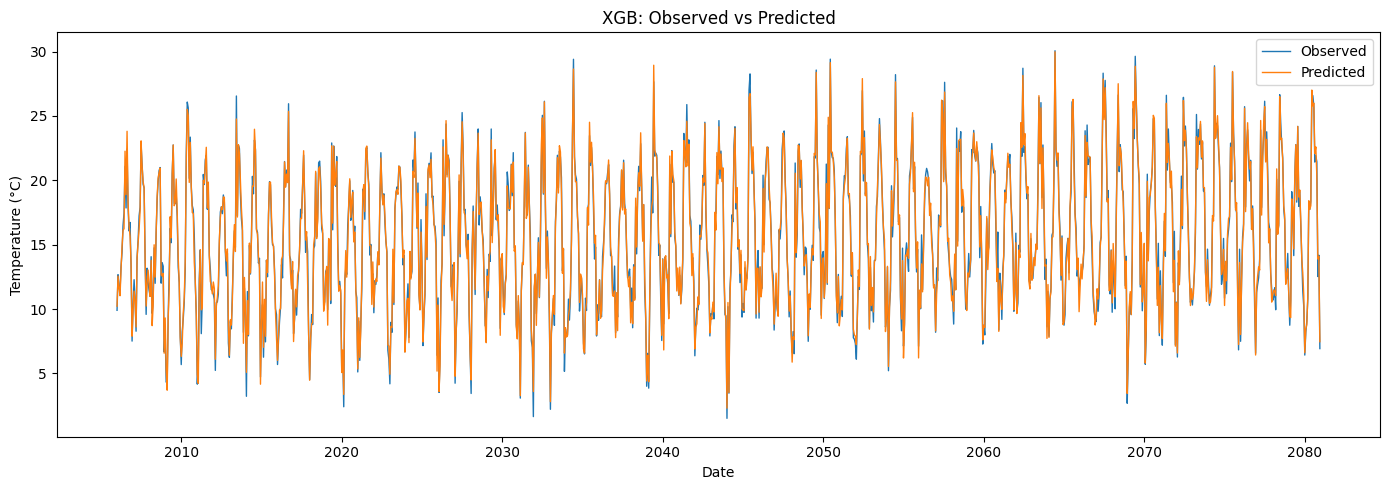

Training LGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2881
[LightGBM] [Info] Number of data points in the train set: 136865, number of used features: 12
[LightGBM] [Info] Start training from score 15.553785
  Model      RMSE       MAE        R2
0  LGBM  0.671311  0.507396  0.983952


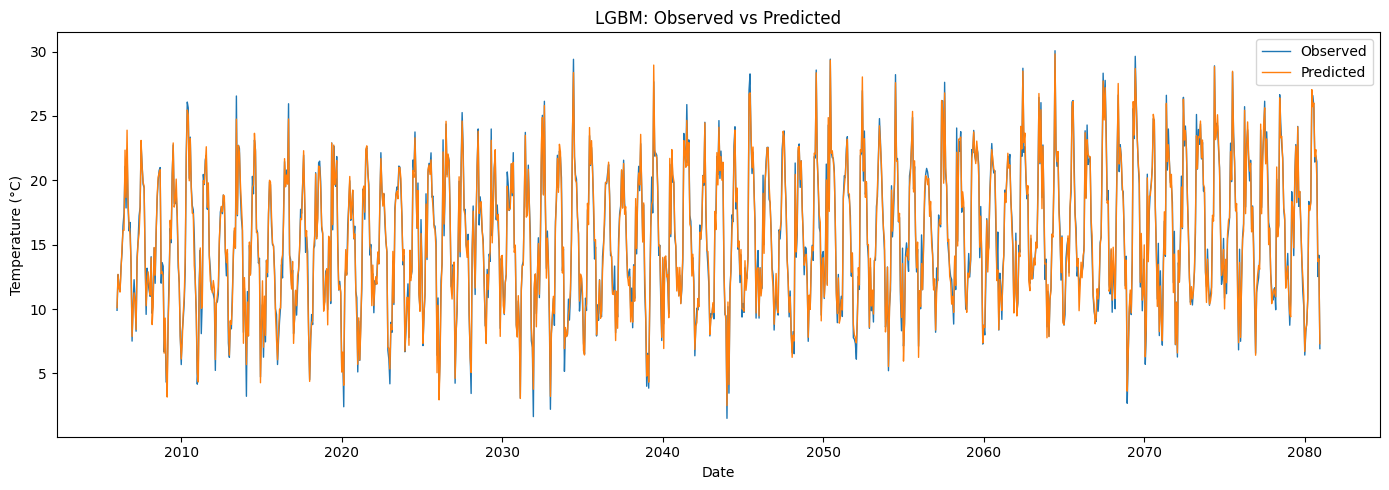

Training RF ...
  Model      RMSE       MAE        R2
0    RF  0.703639  0.536041  0.982369


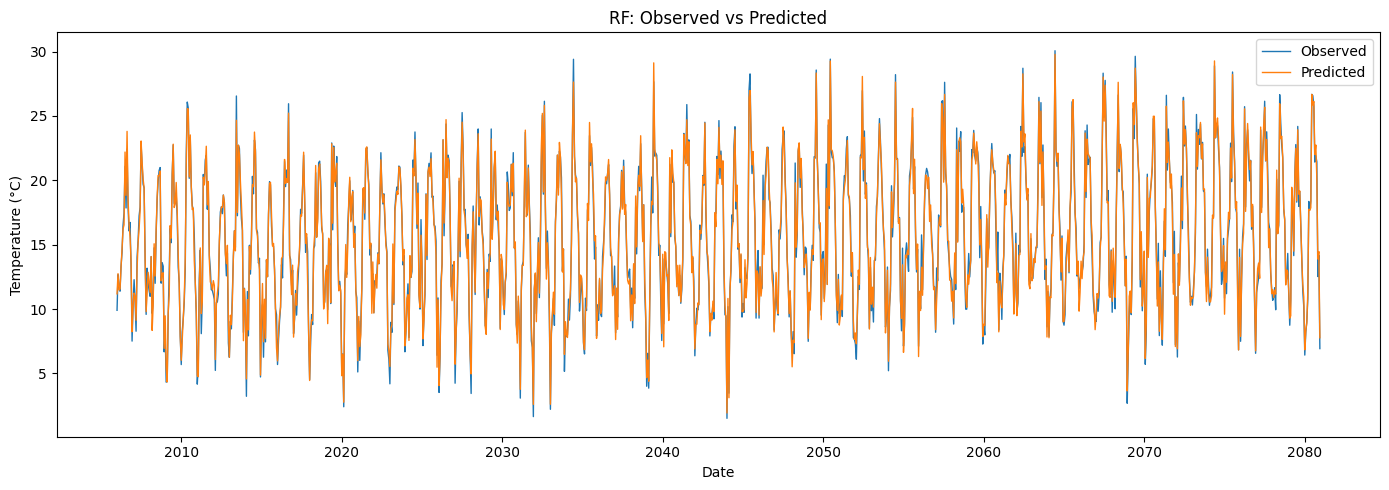

,Model,RMSE,MAE,R2
0,XGB,0.662805,0.500100,0.984356
1,LGBM,0.671311,0.507396,0.983952
2,RF,0.703639,0.536041,0.982369


In [10]:

# ==========================================
# Combined models: XGB + LGBM + RF
# ==========================================
results = []
predictions = {}

models = {
    "XGB": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=RANDOM_STATE
        ))
    ]),
    "LGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE
        ))
    ]),
    "RF": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions[name] = pred
    results.append(evaluate_model(name, y_test, pred))

    print(pd.DataFrame([results[-1]]))
    plot_pred_vs_true(test_dates, y_test, pred, f"{name}: Observed vs Predicted")

results_df_partial = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df_partial


Training SVR on 15000 sampled training rows...
  Model      RMSE       MAE        R2
0   SVR  0.704956  0.508341  0.982303


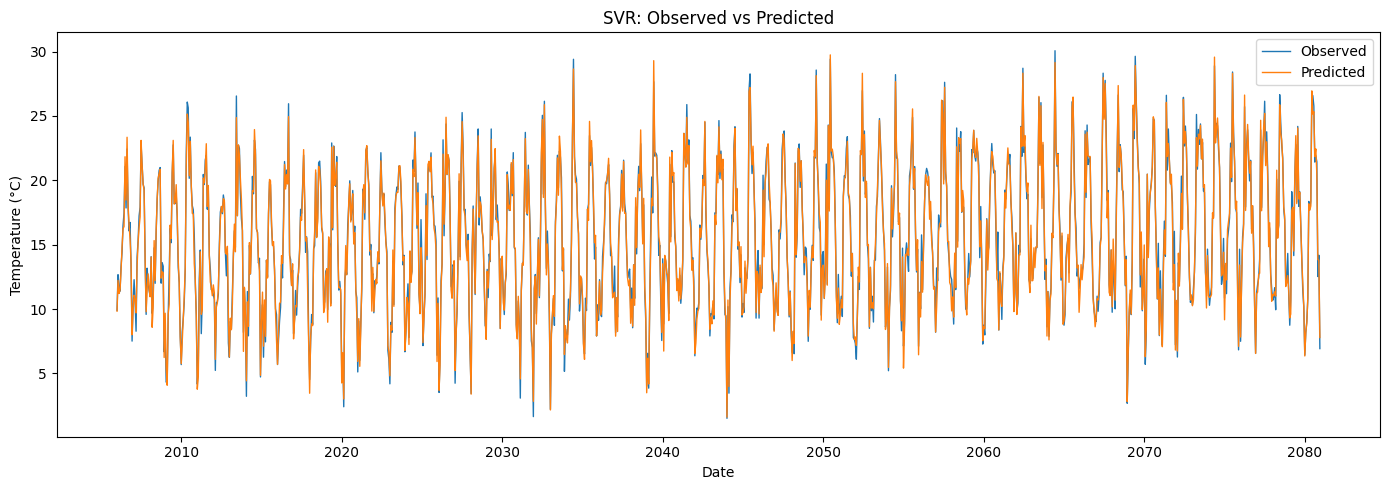

Saved: final_svr_model.joblib
Saved: final_svr_scaler.joblib


In [11]:

# ==========================================
# Final SVR (kept as a dedicated section)
# ==========================================
scaler_svr = StandardScaler()
X_train_scaled = scaler_svr.fit_transform(X_train)
X_test_scaled = scaler_svr.transform(X_test)

np.random.seed(RANDOM_STATE)
sample_size = min(SVR_SAMPLE_SIZE, len(X_train_scaled))
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)

print(f"Training SVR on {sample_size} sampled training rows...")
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train_scaled[indices], y_train.iloc[indices])

svr_pred = svr_model.predict(X_test_scaled)

predictions["SVR"] = svr_pred
results.append(evaluate_model("SVR", y_test, svr_pred))

print(pd.DataFrame([results[-1]]))
plot_pred_vs_true(test_dates, y_test, svr_pred, "SVR: Observed vs Predicted")

# Save the final SVR model and its scaler
joblib.dump(svr_model, "final_svr_model.joblib")
joblib.dump(scaler_svr, "final_svr_scaler.joblib")
print("Saved: final_svr_model.joblib")
print("Saved: final_svr_scaler.joblib")


Number of PCA components retained: 7
Training SVR_PCA on 15000 sampled training rows...
     Model      RMSE       MAE        R2
0  SVR_PCA  0.952909  0.723476  0.967664


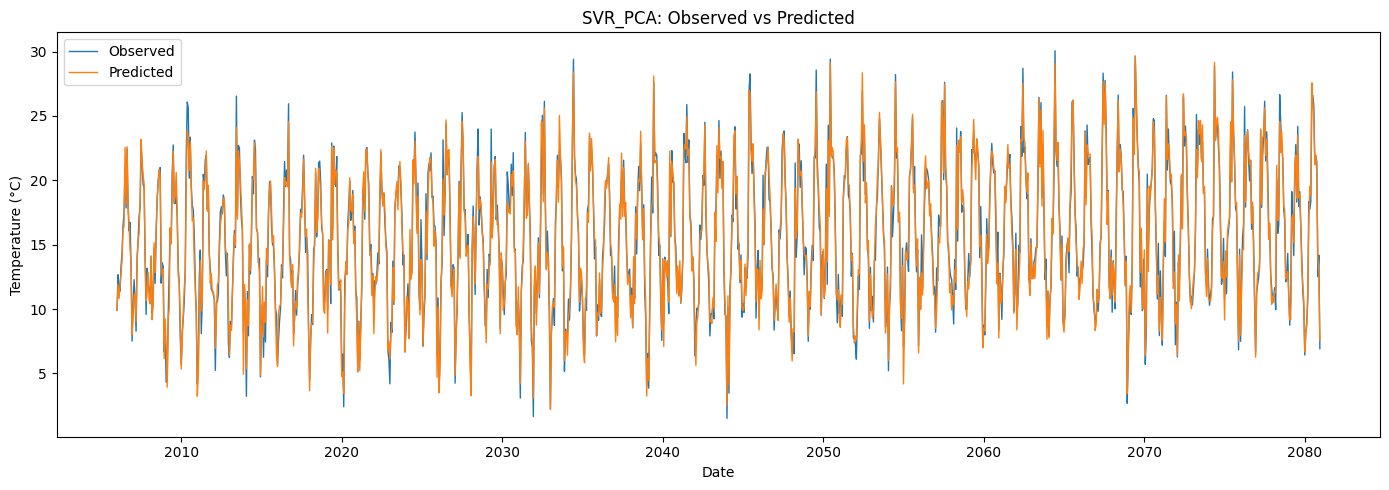

Saved: svr_pca_model.joblib


In [12]:

# ==========================================
# SVR + PCA
# ==========================================
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train)
X_test_scaled_pca = scaler_pca.transform(X_test)

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled_pca)
X_test_pca = pca.transform(X_test_scaled_pca)

np.random.seed(RANDOM_STATE)
sample_size = min(SVR_SAMPLE_SIZE, len(X_train_pca))
indices = np.random.choice(len(X_train_pca), sample_size, replace=False)

print(f"Number of PCA components retained: {pca.n_components_}")
print(f"Training SVR_PCA on {sample_size} sampled training rows...")

svr_pca_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_pca_model.fit(X_train_pca[indices], y_train.iloc[indices])

svr_pca_pred = svr_pca_model.predict(X_test_pca)

predictions["SVR_PCA"] = svr_pca_pred
results.append(evaluate_model("SVR_PCA", y_test, svr_pca_pred))

print(pd.DataFrame([results[-1]]))
plot_pred_vs_true(test_dates, y_test, svr_pca_pred, "SVR_PCA: Observed vs Predicted")

joblib.dump(svr_pca_model, "svr_pca_model.joblib")
joblib.dump(scaler_pca, "svr_pca_scaler.joblib")
joblib.dump(pca, "svr_pca_transform.joblib")
print("Saved: svr_pca_model.joblib")


     Model      RMSE       MAE        R2
0      XGB  0.662805  0.500100  0.984356
1     LGBM  0.671311  0.507396  0.983952
2       RF  0.703639  0.536041  0.982369
3      SVR  0.704956  0.508341  0.982303
4  SVR_PCA  0.952909  0.723476  0.967664


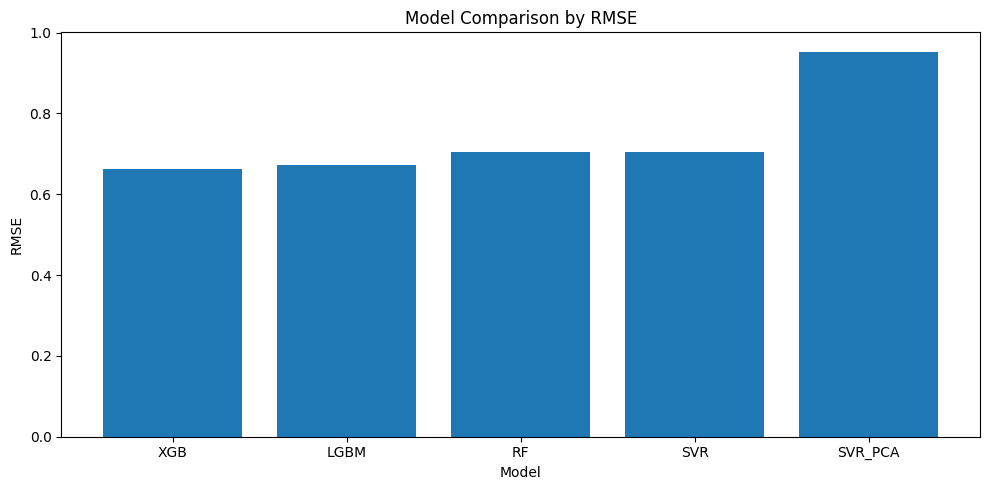

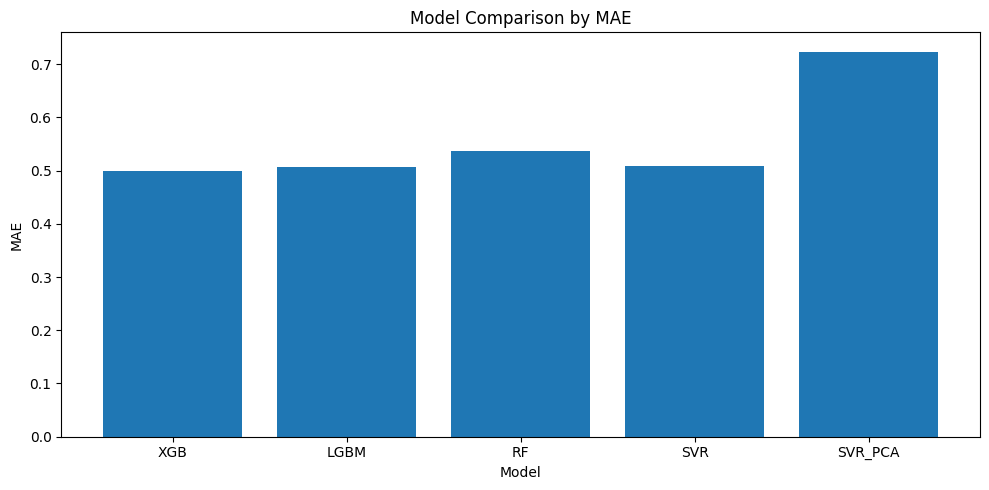

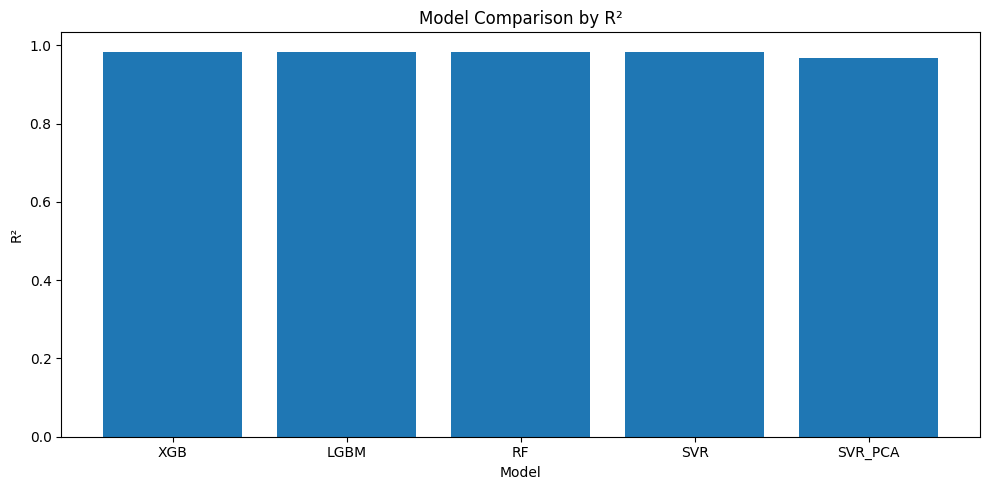

In [14]:

# ==========================================
# Final comparison
# ==========================================
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()


In [15]:

# ==========================================
# Export best model predictions
# ==========================================
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

comparison_df = pd.DataFrame({
    "Date": test_dates.values,
    "Observed": y_test.values,
    "Predicted": best_pred
})

comparison_df.to_csv("best_model_predictions.csv", index=False)
results_df.to_csv("model_comparison_metrics.csv", index=False)

print("Best model:", best_model_name)
print("Saved: best_model_predictions.csv")
print("Saved: model_comparison_metrics.csv")
comparison_df.head()


Best model: XGB
Saved: best_model_predictions.csv
Saved: model_comparison_metrics.csv


,Date,Observed,Predicted
0,2006-01-02,9.898920,10.220398
1,2006-01-03,9.951624,10.203527
2,2006-01-04,10.907678,10.247966
3,2006-01-05,10.001062,8.987013
4,2006-01-06,7.851343,8.281124
